In [4]:
import zipfile
import os

zip_file_path = '/content/shoes.zip'
destination_folder = '/content/shoes'

os.makedirs(destination_folder, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(destination_folder)

print(f'Unzipped files are in {destination_folder}')


Unzipped files are in /content/shoes


In [5]:
!pip install tensorflow matplotlib scikit-learn visualkeras seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 993.7/993.7 kB 20.4 MB/s eta 0:00:00


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import visualkeras
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, precision_recall_fscore_support



In [7]:
# Directories for train and test sets
train_dir = 'shoes/train'
test_dir = 'shoes/test'

# Data generators for scaling and augmentation
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train data loader
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

# Test data loader
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 711 images belonging to 3 classes.
Found 114 images belonging to 3 classes.


In [27]:
model = tf.keras.models.Sequential([
    layers.Conv2D(16, (3, 3), input_shape=(150, 150, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Dropout(0.5),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/usr/local/lib/python3.10/dist-packages/visualkeras/layered.py:86: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


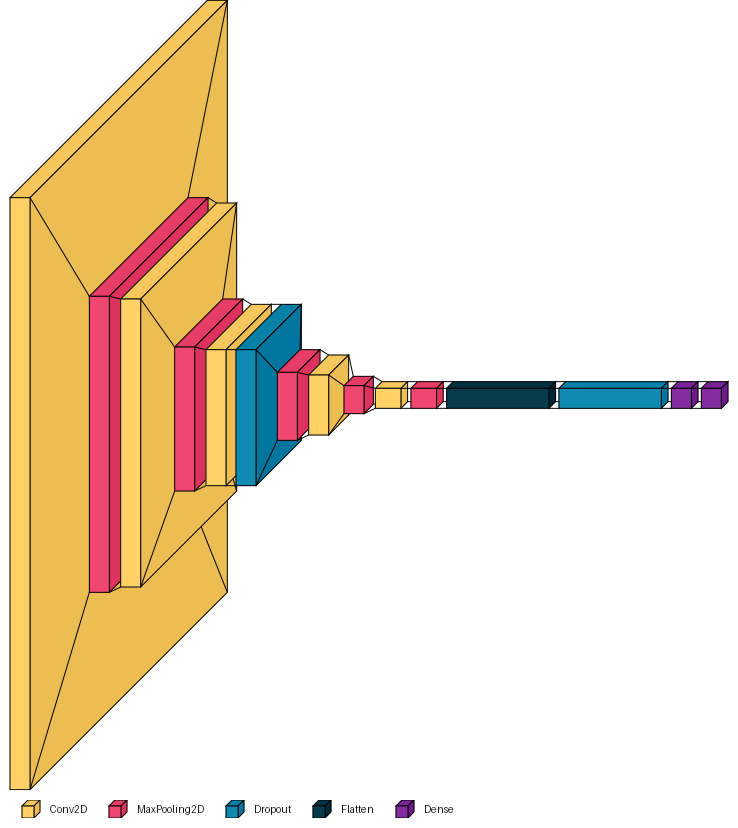

In [28]:
import PIL.Image

# Create and save model visualization
visualization = visualkeras.layered_view(
    model,
    legend=True,
    draw_volume=True
)
visualization.save('/content/model_architecture_visualkeras.png')

# Display the saved image
from IPython.display import Image
Image('/content/model_architecture_visualkeras.png')


In [29]:
# Early stopping callback
callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=10)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[callback]
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 188ms/step - accuracy: 0.3060 - loss: 1.1297 - val_accuracy: 0.3333 - val_loss: 1.0961
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.3505 - loss: 1.0972 - val_accuracy: 0.3246 - val_loss: 1.0945
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.3716 - loss: 1.0977 - val_accuracy: 0.4386 - val_loss: 1.0887
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3886 - loss: 1.0887 - val_accuracy: 0.4474 - val_loss: 1.0832
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4233 - loss: 1.0834 - val_accuracy: 0.4123 - val_loss: 1.0782
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4462 - loss: 1.0663 - val_accuracy: 0.4825 - val_loss: 1.0572
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4288 - loss: 1.0450 - val_accuracy: 0.4386 - val_loss: 1.0567
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.4663 - loss: 1.0356 - val_accuracy: 0.4474 -

In [30]:

test_generator.reset()


predictions = model.predict(test_generator)
predicted_classes = predictions.argmax(axis=1)


true_classes = test_generator.classes


class_labels = list(test_generator.class_indices.keys())


report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)


precision, recall, f1_score, _ = precision_recall_fscore_support(
    true_classes, predicted_classes, average='macro'
)
print(f"Precision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1 Score (Macro): {f1_score:.2f}")


precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(
    true_classes, predicted_classes, average='micro'
)
print(f"Precision (Micro): {precision_micro:.2f}")
print(f"Recall (Micro): {recall_micro:.2f}")
print(f"F1 Score (Micro): {f1_micro:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step
              precision    recall  f1-score   support

      adidas       0.50      0.71      0.59        38
    converse       0.68      0.45      0.54        38
        nike       0.49      0.45      0.47        38

    accuracy                           0.54       114
   macro avg       0.56      0.54      0.53       114
weighted avg       0.56      0.54      0.53       114

Precision (Macro): 0.56
Recall (Macro): 0.54
F1 Score (Macro): 0.53
Precision (Micro): 0.54
Recall (Micro): 0.54
F1 Score (Micro): 0.54


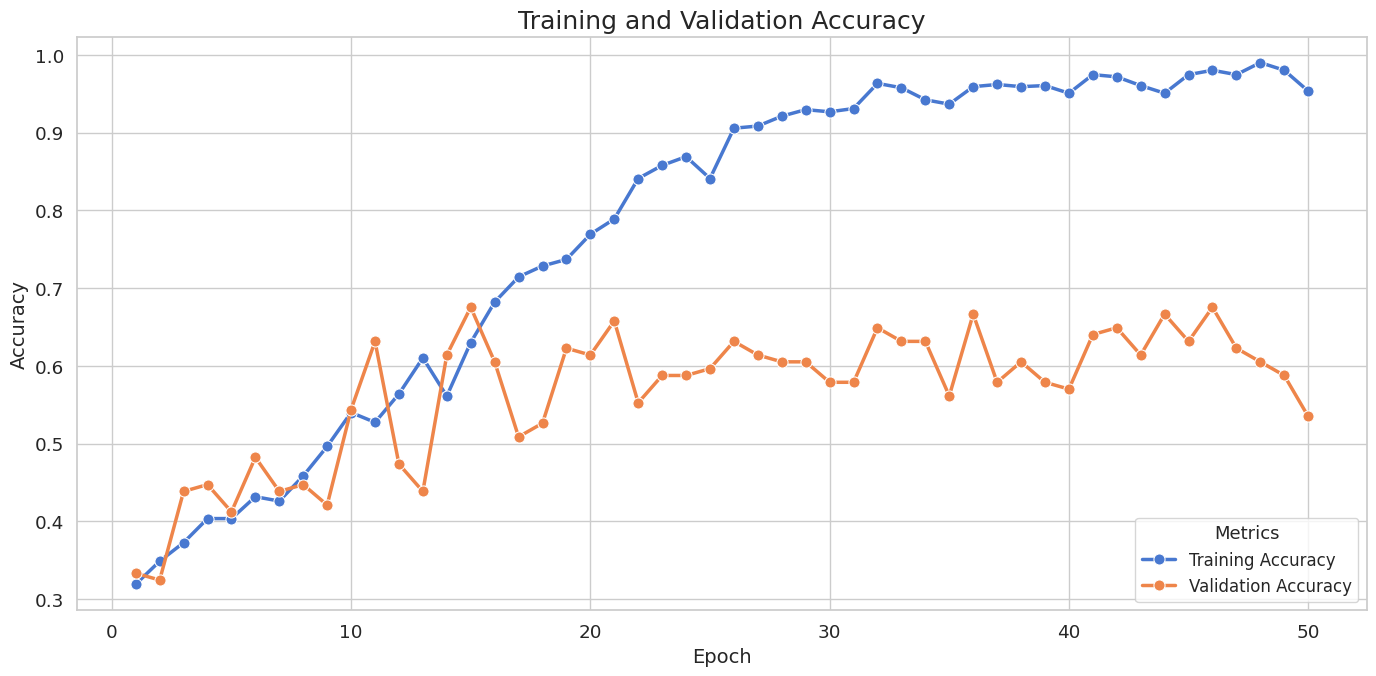

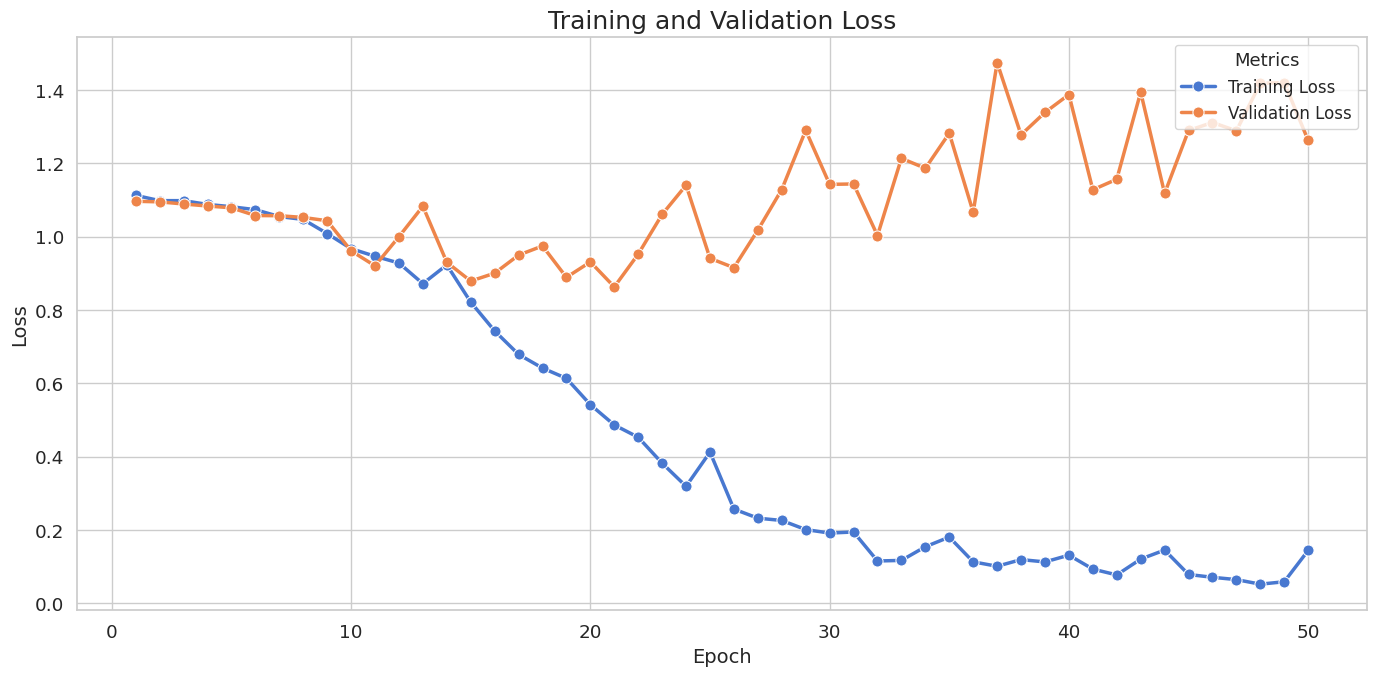

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set(style="whitegrid", palette="muted", font_scale=1.2)

history_dict = {
    'epoch': range(1, len(history.history['accuracy']) + 1),
    'Training Accuracy': history.history['accuracy'],
    'Validation Accuracy': history.history['val_accuracy'],
    'Training Loss': history.history['loss'],
    'Validation Loss': history.history['val_loss']
}


history_df = pd.DataFrame(history_dict)


plt.figure(figsize=(14, 7))


sns.lineplot(x='epoch', y='value', hue='variable',
             data=pd.melt(history_df, ['epoch'], value_vars=['Training Accuracy', 'Validation Accuracy']),
             linewidth=2.5, marker="o", markersize=8)


plt.title('Training and Validation Accuracy', fontsize=18)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(title='Metrics', fontsize=12, title_fontsize='13', loc='lower right')
plt.grid(True)


plt.tight_layout()
plt.show()


plt.figure(figsize=(14, 7))


sns.lineplot(x='epoch', y='value', hue='variable',
             data=pd.melt(history_df, ['epoch'], value_vars=['Training Loss', 'Validation Loss']),
             linewidth=2.5, marker="o", markersize=8)


plt.title('Training and Validation Loss', fontsize=18)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(title='Metrics', fontsize=12, title_fontsize='13', loc='upper right')
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()


In [32]:
model.save('/content/shoe_classifier_model.h5')


In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, precision_recall_fscore_support
import pandas as pd
import numpy as np

def create_model(filters=(16, 32, 64, 128, 256), dropout_rate=0.5, learning_rate=0.001):
    model = tf.keras.models.Sequential([
        layers.Conv2D(filters[0], (3, 3), input_shape=(150, 150, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters[1], (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters[2], (3, 3), activation='relu'),
        layers.Dropout(dropout_rate),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters[3], (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(filters[4], (3, 3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    return model


train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20, zoom_range=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'shoes/train',  # Update with actual path
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    'shoes/test',  # Update with actual path
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


results = []

# ---------------------------- 1. Test Filters Independently ----------------------------
filter_combinations = [
    (16, 32, 64, 128, 256),
    (32, 64, 128, 256, 512),
    (64, 128, 256, 512, 1024)
]

for filters in filter_combinations:
    print(f"Training with filters={filters}")

    model = create_model(filters=filters, dropout_rate=0.5, learning_rate=0.001)


    callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=10)

 
    history = model.fit(
        train_generator,
        epochs=12,
        validation_data=test_generator,
        callbacks=[callback]
    )

   
    test_generator.reset()

  
    predictions = model.predict(test_generator)
    predicted_classes = predictions.argmax(axis=1)

  
    true_classes = test_generator.classes

   
    report = classification_report(true_classes, predicted_classes, target_names=list(test_generator.class_indices.keys()))


    precision, recall, f1_score, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='macro')
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='micro')

 
    results.append({
        'Filters': filters,
        'Dropout Rate': 0.5,
        'Learning Rate': 0.001,
        'Training Accuracy': history.history['accuracy'][-1],
        'Validation Accuracy': history.history['val_accuracy'][-1],
        'Training Loss': history.history['loss'][-1],
        'Validation Loss': history.history['val_loss'][-1],
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1_score,
        'Precision (Micro)': precision_micro,
        'Recall (Micro)': recall_micro,
        'F1 Score (Micro)': f1_micro,
        'Classification Report': report
    })

# ---------------------------- 2. Test Dropout Rate Independently ----------------------------
dropout_rates = [0.3, 0.5, 0.7]

for rate in dropout_rates:
    print(f"Training with dropout_rate={rate}")

    model = create_model(filters=(16, 32, 64, 128, 256), dropout_rate=rate, learning_rate=0.001)

    callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=10)


    history = model.fit(
        train_generator,
        epochs=12,
        validation_data=test_generator,
        callbacks=[callback]
    )

   
    test_generator.reset()


    predictions = model.predict(test_generator)
    predicted_classes = predictions.argmax(axis=1)

   
    true_classes = test_generator.classes

    
    report = classification_report(true_classes, predicted_classes, target_names=list(test_generator.class_indices.keys()))

   
    precision, recall, f1_score, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='macro')
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='micro')

 
    results.append({
        'Filters': (16, 32, 64, 128, 256),
        'Dropout Rate': rate,
        'Learning Rate': 0.001,
        'Training Accuracy': history.history['accuracy'][-1],
        'Validation Accuracy': history.history['val_accuracy'][-1],
        'Training Loss': history.history['loss'][-1],
        'Validation Loss': history.history['val_loss'][-1],
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1_score,
        'Precision (Micro)': precision_micro,
        'Recall (Micro)': recall_micro,
        'F1 Score (Micro)': f1_micro,
        'Classification Report': report
    })

# ---------------------------- 3. Test Learning Rate Independently ----------------------------
learning_rates = [0.0001, 0.001, 0.01]

for lr in learning_rates:
    print(f"Training with learning_rate={lr}")

    model = create_model(filters=(16, 32, 64, 128, 256), dropout_rate=0.5, learning_rate=lr)

    # Early stopping callback
    callback = tf.keras.callbacks.EarlyStopping(monitor='accuracy', patience=10)

    # Train the model
    history = model.fit(
        train_generator,
        epochs=12,
        validation_data=test_generator,
        callbacks=[callback]
    )


    test_generator.reset()

   
    predictions = model.predict(test_generator)
    predicted_classes = predictions.argmax(axis=1)

 
    true_classes = test_generator.classes


    report = classification_report(true_classes, predicted_classes, target_names=list(test_generator.class_indices.keys()))

 
    precision, recall, f1_score, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='macro')
    precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(true_classes, predicted_classes, average='micro')

 
    results.append({
        'Filters': (16, 32, 64, 128, 256),
        'Dropout Rate': 0.5,
        'Learning Rate': lr,
        'Training Accuracy': history.history['accuracy'][-1],
        'Validation Accuracy': history.history['val_accuracy'][-1],
        'Training Loss': history.history['loss'][-1],
        'Validation Loss': history.history['val_loss'][-1],
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1_score,
        'Precision (Micro)': precision_micro,
        'Recall (Micro)': recall_micro,
        'F1 Score (Micro)': f1_micro,
        'Classification Report': report
    })


results_df = pd.DataFrame(results)

print("Results Summary:")
print(results_df[['Filters', 'Dropout Rate', 'Learning Rate', 'Training Accuracy', 'Validation Accuracy',
                  'Precision (Macro)', 'Recall (Macro)', 'F1 Score (Macro)', 'Precision (Micro)',
                  'Recall (Micro)', 'F1 Score (Micro)']])


for idx, result in results_df.iterrows():
    print(f"\nClassification Report for filters={result['Filters']}, dropout_rate={result['Dropout Rate']}, learning_rate={result['Learning Rate']}:")
    print(result['Classification Report'])


Found 711 images belonging to 3 classes.
Found 114 images belonging to 3 classes.
Training with filters=(16, 32, 64, 128, 256)


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 294ms/step - accuracy: 0.3161 - loss: 1.1195 - val_accuracy: 0.3333 - val_loss: 1.0974
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 124ms/step - accuracy: 0.3372 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.0975
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - accuracy: 0.3612 - loss: 1.0978 - val_accuracy: 0.3333 - val_loss: 1.0986
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.3386 - loss: 1.0986 - val_accuracy: 0.3333 - val_loss: 1.0983
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.3880 - loss: 1.0969 - val_accuracy: 0.3246 - val_loss: 1.0979
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 180ms/step - accuracy: 0.3310 - loss: 1.0990 - val_accuracy: 0.4035 - val_loss: 1.0959
Epoch 7/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.3489 - loss: 1.0977 - val_accuracy: 0.3333 - val_loss: 1.0889
Epoch 8/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.3073 - loss: 1.1102 - val_accuracy: 0.3947 - va

...

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 294ms/step - accuracy: 0.3275 - loss: 1.1119 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 126ms/step - accuracy: 0.3280 - loss: 1.1010 - val_accuracy: 0.3684 - val_loss: 1.0882
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step - accuracy: 0.3285 - loss: 1.0962 - val_accuracy: 0.4737 - val_loss: 1.0955
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 180ms/step - accuracy: 0.3440 - loss: 1.0977 - val_accuracy: 0.4386 - val_loss: 1.0856
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.3578 - loss: 1.0916 - val_accuracy: 0.4035 - val_loss: 1.0879
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.3761 - loss: 1.0875 - val_accuracy: 0.3333 - val_loss: 1.1011
Epoch 7/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 142ms/step - accuracy: 0.3039 - loss: 1.1059 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 8/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.3556 - loss: 1.0983 - val_accuracy: 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Epoch 1/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 268ms/step - accuracy: 0.3682 - loss: 8.7459 - val_accuracy: 0.3333 - val_loss: 1.0991
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 124ms/step - accuracy: 0.3215 - loss: 1.1005 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.3003 - loss: 1.0999 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.3401 - loss: 1.0983 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.3668 - loss: 1.0994 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.3099 - loss: 1.1009 - val_accuracy: 0.3333 - val_loss: 1.0989
Epoch 7/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 123ms/step - accuracy: 0.3427 - loss: 1.0990 - val_accuracy: 0.3333 - val_loss: 1.0990
Epoch 8/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.3514 - loss: 1.0981 - val_accuracy: 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


/usr/local/lib/python3.10/dist-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(file, map_location=device, **torch_load_kwargs

epoch,train_loss,valid_loss,accuracy,time
0,1.745290,0.993956,0.753521,00:05
1,1.221949,0.854434,0.739437,00:05
2,0.929259,0.683965,0.781690,00:05
3,0.729544,1.020939,0.732394,00:05
4,0.667582,1.014331,0.746479,00:05
5,0.662564,1.372379,0.718310,00:05
6,0.650811,1.727040,0.753521,00:05
7,0.705043,2.640611,0.739437,00:05
8,0.878784,1.600780,0.830986,00:05
9,0.932188,2.229119,0.802817,00:05


Validation Loss: 1.5920, Validation Accuracy: 0.8944


              precision    recall  f1-score   support

      adidas       0.85      0.89      0.87        37
    converse       0.91      0.89      0.90        55
        nike       0.92      0.90      0.91        50

    accuracy                           0.89       142
   macro avg       0.89      0.89      0.89       142
weighted avg       0.90      0.89      0.89       142

Precision (Macro): 0.89
Recall (Macro): 0.89
F1 Score (Macro): 0.89
Precision (Micro): 0.89
Recall (Micro): 0.89
F1 Score (Micro): 0.89


Path('shoes/../kaggle/working/resnet50_model.pth')

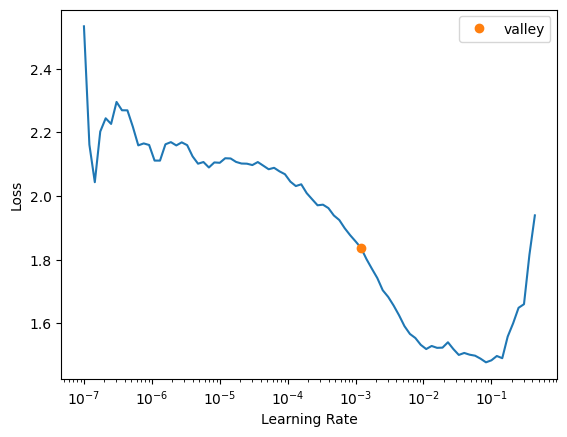

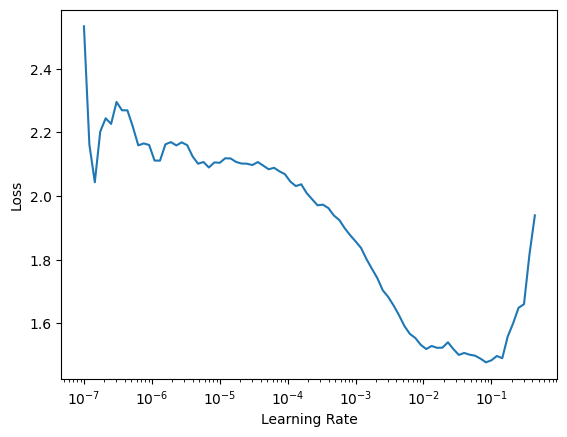

In [ ]:
from fastai.vision.all import *
import os
from pathlib import Path
from sklearn.metrics import classification_report, precision_recall_fscore_support
import torch.nn as nn

path = Path('shoes') 
train_path = path / 'train' 
valid_path = path / 'test'

dls = ImageDataLoaders.from_folder(path, train='train', valid='test', bs=32, item_tfms=Resize(224), batch_tfms=aug_transforms(size=224))

class CustomCNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = resnet50(pretrained=True)
        self.backbone.fc = nn.Identity()

        self.head = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)

learn = cnn_learner(dls, CustomCNNModel, metrics=[accuracy], model_dir=Path('../kaggle/working'), path=path)

learn.lr_find()
learn.recorder.plot_lr_find()

lr1 = 1e-3  
lr2 = 1e-1  

with learn.no_logging():
    learn.fit_one_cycle(70, slice(lr1, lr2))

val_loss, val_accuracy = learn.validate()
print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

preds, targs = learn.get_preds()
pred_labels = preds.argmax(dim=1)

class_labels = dls.vocab  

report = classification_report(targs, pred_labels, target_names=class_labels)
print(report)

precision, recall, f1_score, _ = precision_recall_fscore_support(targs, pred_labels, average='macro')
print(f"Precision (Macro): {precision:.2f}")
print(f"Recall (Macro): {recall:.2f}")
print(f"F1 Score (Macro): {f1_score:.2f}")

precision_micro, recall_micro, f1_micro, _ = precision_recall_fscore_support(targs, pred_labels, average='micro')
print(f"Precision (Micro): {precision_micro:.2f}")
print(f"Recall (Micro): {recall_micro:.2f}")
print(f"F1 Score (Micro): {f1_micro:.2f}")
